# Bone Fracture Detection Using Faster R-CNN

This notebook trains a Faster R-CNN model on the same BoneFractureYolo8 dataset
and compares its performance (mAP) with the YOLOv8 model.

### Import Libraries

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

DEVICE = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f'Using device: {DEVICE}')

PyTorch version: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Ti
Using device: cuda


### Setup Paths & Class Names

In [2]:
BASE_PATH = "../BoneFractureYolo8"

train_images = os.path.join(BASE_PATH, "train", "images")
train_labels = os.path.join(BASE_PATH, "train", "labels")

val_images   = os.path.join(BASE_PATH, "valid", "images")
val_labels   = os.path.join(BASE_PATH, "valid", "labels")

test_images  = os.path.join(BASE_PATH, "test", "images")
test_labels  = os.path.join(BASE_PATH, "test", "labels")

# After merging 'humerus fracture' into 'humerus' (done in EditData.ipynb)
# 6 fracture classes + 1 background = 7 total
CLASS_NAMES = [
    '__background__',
    'elbow positive',
    'fingers positive',
    'forearm fracture',
    'humerus',
    'shoulder fracture',
    'wrist positive'
]
NUM_CLASSES = len(CLASS_NAMES)  # 7
print(f'Number of classes (including background): {NUM_CLASSES}')

Number of classes (including background): 7


### Dataset Class

YOLO OBB labels use the format: `class x1 y1 x2 y2 x3 y3 x4 y4` (normalized 0-1).  
We convert each OBB to an axis-aligned bounding box `[xmin, ymin, xmax, ymax]` in pixel coordinates for Faster R-CNN.

In [3]:
def obb_to_aabb(coords, img_w, img_h):
    """Convert normalized OBB (x1,y1,...,x4,y4) to axis-aligned bbox in pixels."""
    xs = [coords[i] * img_w for i in range(0, 8, 2)]
    ys = [coords[i] * img_h for i in range(1, 8, 2)]
    return [min(xs), min(ys), max(xs), max(ys)]


def parse_label_file(label_path, img_w, img_h):
    """Parse a YOLO OBB label file and return boxes and labels."""
    boxes, labels = [], []
    if not os.path.exists(label_path) or os.path.getsize(label_path) == 0:
        return boxes, labels
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 9:
                continue
            cls  = int(parts[0]) + 1  # +1 because index 0 is background
            coords = list(map(float, parts[1:9]))
            box = obb_to_aabb(coords, img_w, img_h)
            # Skip degenerate boxes
            if box[2] > box[0] and box[3] > box[1]:
                boxes.append(box)
                labels.append(cls)
    return boxes, labels


class BoneFractureDataset(Dataset):
    def __init__(self, images_dir, labels_dir, transforms=None):
        self.images_dir  = images_dir
        self.labels_dir  = labels_dir
        self.transforms  = transforms
        self.image_files = sorted([
            f for f in os.listdir(images_dir)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name   = self.image_files[idx]
        img_path   = os.path.join(self.images_dir, img_name)
        label_path = os.path.join(self.labels_dir, os.path.splitext(img_name)[0] + '.txt')

        img = Image.open(img_path).convert('RGB')
        img_w, img_h = img.size

        boxes, labels = parse_label_file(label_path, img_w, img_h)

        # Handle images with no annotations
        if len(boxes) == 0:
            boxes  = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,),   dtype=torch.int64)
            area   = torch.zeros((0,),   dtype=torch.float32)
        else:
            boxes  = torch.as_tensor(boxes,  dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)
            area   = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])

        target = {
            'boxes':     boxes,
            'labels':    labels,
            'image_id':  torch.tensor([idx]),
            'area':      area,
            'iscrowd':   torch.zeros((len(labels),), dtype=torch.int64)
        }

        if self.transforms:
            img = self.transforms(img)

        return img, target


img_transform = transforms.Compose([transforms.ToTensor()])

train_dataset = BoneFractureDataset(train_images, train_labels, transforms=img_transform)
val_dataset   = BoneFractureDataset(val_images,   val_labels,   transforms=img_transform)
test_dataset  = BoneFractureDataset(test_images,  test_labels,  transforms=img_transform)

print(f'Train: {len(train_dataset)} images')
print(f'Val:   {len(val_dataset)}   images')
print(f'Test:  {len(test_dataset)}  images')

Train: 3631 images
Val:   348   images
Test:  169  images


### DataLoaders

In [4]:
def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True,
                          num_workers=0, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=4, shuffle=False,
                          num_workers=0, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset,  batch_size=4, shuffle=False,
                          num_workers=0, collate_fn=collate_fn)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches:   {len(val_loader)}')

Train batches: 908
Val batches:   87


### Build Faster R-CNN Model

We use a pretrained ResNet-50 FPN backbone and replace the classification head
with our own (6 fracture classes + 1 background).

In [5]:
def build_model(num_classes):
    # Load pretrained Faster R-CNN
    model = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)
    # Replace the classifier head
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

model = build_model(NUM_CLASSES)
model.to(DEVICE)
print('Faster R-CNN model ready!')
print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')

Faster R-CNN model ready!
Total parameters: 41,324,786


### Training

In [6]:
NUM_EPOCHS = 10

optimizer = torch.optim.SGD(
    [p for p in model.parameters() if p.requires_grad],
    lr=0.005, momentum=0.9, weight_decay=0.0005
)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

train_losses = []

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0.0
    loop = tqdm(train_loader, desc=f'Epoch {epoch+1}/{NUM_EPOCHS}')

    for images, targets in loop:
        images  = [img.to(DEVICE) for img in images]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses    = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        epoch_loss += losses.item()
        loop.set_postfix(loss=losses.item())

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    lr_scheduler.step()
    print(f'Epoch {epoch+1}/{NUM_EPOCHS} — Avg Loss: {avg_loss:.4f}')

print('\nTraining complete!')

Epoch 1/10: 100%|██████████████████████████████████████████████████████| 908/908 [1:16:31<00:00,  5.06s/it, loss=0.127]


Epoch 1/10 — Avg Loss: 0.1720


Epoch 2/10: 100%|██████████████████████████████████████████████████████| 908/908 [1:04:41<00:00,  4.27s/it, loss=0.178]


Epoch 2/10 — Avg Loss: 0.1463


Epoch 3/10: 100%|███████████████████████████████████████████████████████| 908/908 [58:23<00:00,  3.86s/it, loss=0.0424]


...

Epoch 8/10 — Avg Loss: 0.0559


Epoch 9/10: 100%|██████████████████████████████████████████████████████| 908/908 [40:47<00:00,  2.70s/it, loss=0.00136]


Epoch 9/10 — Avg Loss: 0.0552


Epoch 10/10: 100%|██████████████████████████████████████████████████████| 908/908 [44:03<00:00,  2.91s/it, loss=0.0496]

Epoch 10/10 — Avg Loss: 0.0545

Training complete!


### Plot Training Loss

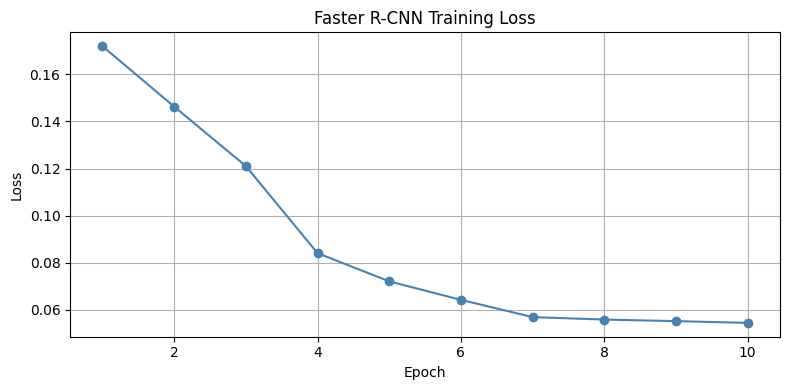

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, NUM_EPOCHS + 1), train_losses, marker='o', color='steelblue')
plt.title('Faster R-CNN Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.tight_layout()
plt.show()

### Save Model

In [8]:
save_path = 'D:/faster_rcnn_bone_fracture.pth'
torch.save(model.state_dict(), save_path)
print(f'Model saved to {save_path}')

Model saved to D:/faster_rcnn_bone_fracture.pth


### Evaluation — Compute mAP

We use `torchmetrics` to compute mAP@50 and mAP@50-95 on the test set,
matching the metrics reported by YOLOv8.

In [7]:
import os
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tqdm import tqdm
from torchmetrics.detection.mean_ap import MeanAveragePrecision
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Paths
BASE_PATH = "../BoneFractureYolo8"
test_images = os.path.join(BASE_PATH, "test", "images")
test_labels = os.path.join(BASE_PATH, "test", "labels")

CLASS_NAMES = ['__background__', 'elbow positive', 'fingers positive',
               'forearm fracture', 'humerus', 'shoulder fracture', 'wrist positive']
NUM_CLASSES = len(CLASS_NAMES)
DEVICE = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# Dataset
def obb_to_aabb(coords, img_w, img_h):
    xs = [coords[i] * img_w for i in range(0, 8, 2)]
    ys = [coords[i] * img_h for i in range(1, 8, 2)]
    return [min(xs), min(ys), max(xs), max(ys)]

def parse_label_file(label_path, img_w, img_h):
    boxes, labels = [], []
    if not os.path.exists(label_path) or os.path.getsize(label_path) == 0:
        return boxes, labels
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 9:
                continue
            cls = int(parts[0]) + 1
            coords = list(map(float, parts[1:9]))
            box = obb_to_aabb(coords, img_w, img_h)
            if box[2] > box[0] and box[3] > box[1]:
                boxes.append(box)
                labels.append(cls)
    return boxes, labels

class BoneFractureDataset(Dataset):
    def __init__(self, images_dir, labels_dir, transforms=None):
        self.images_dir  = images_dir
        self.labels_dir  = labels_dir
        self.transforms  = transforms
        self.image_files = sorted([f for f in os.listdir(images_dir)
                                   if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    def __len__(self):
        return len(self.image_files)
    def __getitem__(self, idx):
        img_name   = self.image_files[idx]
        img_path   = os.path.join(self.images_dir, img_name)
        label_path = os.path.join(self.labels_dir, os.path.splitext(img_name)[0] + '.txt')
        img = Image.open(img_path).convert('RGB')
        img_w, img_h = img.size
        boxes, labels = parse_label_file(label_path, img_w, img_h)
        if len(boxes) == 0:
            boxes  = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,),   dtype=torch.int64)
            area   = torch.zeros((0,),   dtype=torch.float32)
        else:
            boxes  = torch.as_tensor(boxes,  dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)
            area   = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
        target = {'boxes': boxes, 'labels': labels,
                  'image_id': torch.tensor([idx]), 'area': area,
                  'iscrowd': torch.zeros((len(labels),), dtype=torch.int64)}
        if self.transforms:
            img = self.transforms(img)
        return img, target

def collate_fn(batch):
    return tuple(zip(*batch))

img_transform = transforms.Compose([transforms.ToTensor()])
test_dataset  = BoneFractureDataset(test_images, test_labels, transforms=img_transform)
test_loader   = DataLoader(test_dataset, batch_size=2, shuffle=False,
                           num_workers=0, collate_fn=collate_fn)

# Load model
def build_model(num_classes):
    model = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

model = build_model(NUM_CLASSES)
model.load_state_dict(torch.load('D:/faster_rcnn_bone_fracture.pth', map_location=DEVICE))
model.to(DEVICE)
print('✅ Everything loaded! Ready to evaluate.')

✅ Everything loaded! Ready to evaluate.


In [3]:
!pip install pycocotools --no-cache-dir

In [8]:
!pip install torchmetrics --no-cache-dir

from torchmetrics.detection.mean_ap import MeanAveragePrecision

model.eval()
metric = MeanAveragePrecision(iou_type='bbox')

with torch.no_grad():
    for images, targets in tqdm(test_loader, desc='Evaluating on test set'):
        images = [img.to(DEVICE) for img in images]
        preds  = model(images)

        # Move predictions and targets to CPU for metric computation
        preds_cpu   = [{k: v.cpu() for k, v in p.items()} for p in preds]
        targets_cpu = [{k: v.cpu() for k, v in t.items()} for t in targets]
        metric.update(preds_cpu, targets_cpu)

results = metric.compute()

rcnn_map50    = results['map_50'].item()
rcnn_map5095  = results['map'].item()

print(f'\nFaster R-CNN Results on Test Set:')
print(f'  mAP@50:    {rcnn_map50:.4f}')
print(f'  mAP@50-95: {rcnn_map5095:.4f}')

Evaluating on test set: 100%|██████████████████████████████████████████████████████████| 85/85 [00:12<00:00,  6.86it/s]


Faster R-CNN Results on Test Set:
  mAP@50:    0.2017
  mAP@50-95: 0.0713


### Compare Faster R-CNN vs YOLOv8

Fill in the YOLO results from your `Yolo.ipynb` run below.

                      Model   mAP@50  mAP@50-95
                    YOLOv8n 0.262000   0.100000
Faster R-CNN (ResNet50-FPN) 0.201706   0.071267


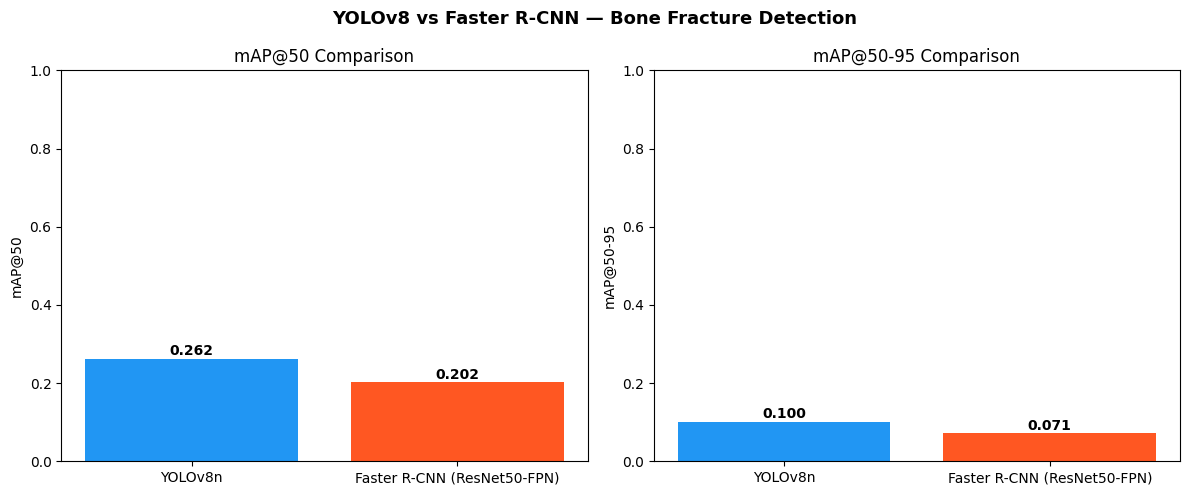

Comparison chart saved to model_comparison.png


In [9]:
# -----------------------------------------------------------
# Fill these in from your Yolo.ipynb results.csv after training
# Look for the best epoch row in: runs/detect/train/results.csv
# -----------------------------------------------------------
yolo_map50   = 0.262
yolo_map5095 = 0.100

# Build comparison table
comparison = pd.DataFrame({
    'Model':      ['YOLOv8n', 'Faster R-CNN (ResNet50-FPN)'],
    'mAP@50':     [yolo_map50,   rcnn_map50],
    'mAP@50-95':  [yolo_map5095, rcnn_map5095]
})
print(comparison.to_string(index=False))

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#2196F3', '#FF5722']

axes[0].bar(comparison['Model'], comparison['mAP@50'], color=colors)
axes[0].set_title('mAP@50 Comparison')
axes[0].set_ylabel('mAP@50')
axes[0].set_ylim(0, 1)
for i, v in enumerate(comparison['mAP@50']):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

axes[1].bar(comparison['Model'], comparison['mAP@50-95'], color=colors)
axes[1].set_title('mAP@50-95 Comparison')
axes[1].set_ylabel('mAP@50-95')
axes[1].set_ylim(0, 1)
for i, v in enumerate(comparison['mAP@50-95']):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.suptitle('YOLOv8 vs Faster R-CNN — Bone Fracture Detection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()
print('Comparison chart saved to model_comparison.png')

### Visualize Predictions on Sample Test Images

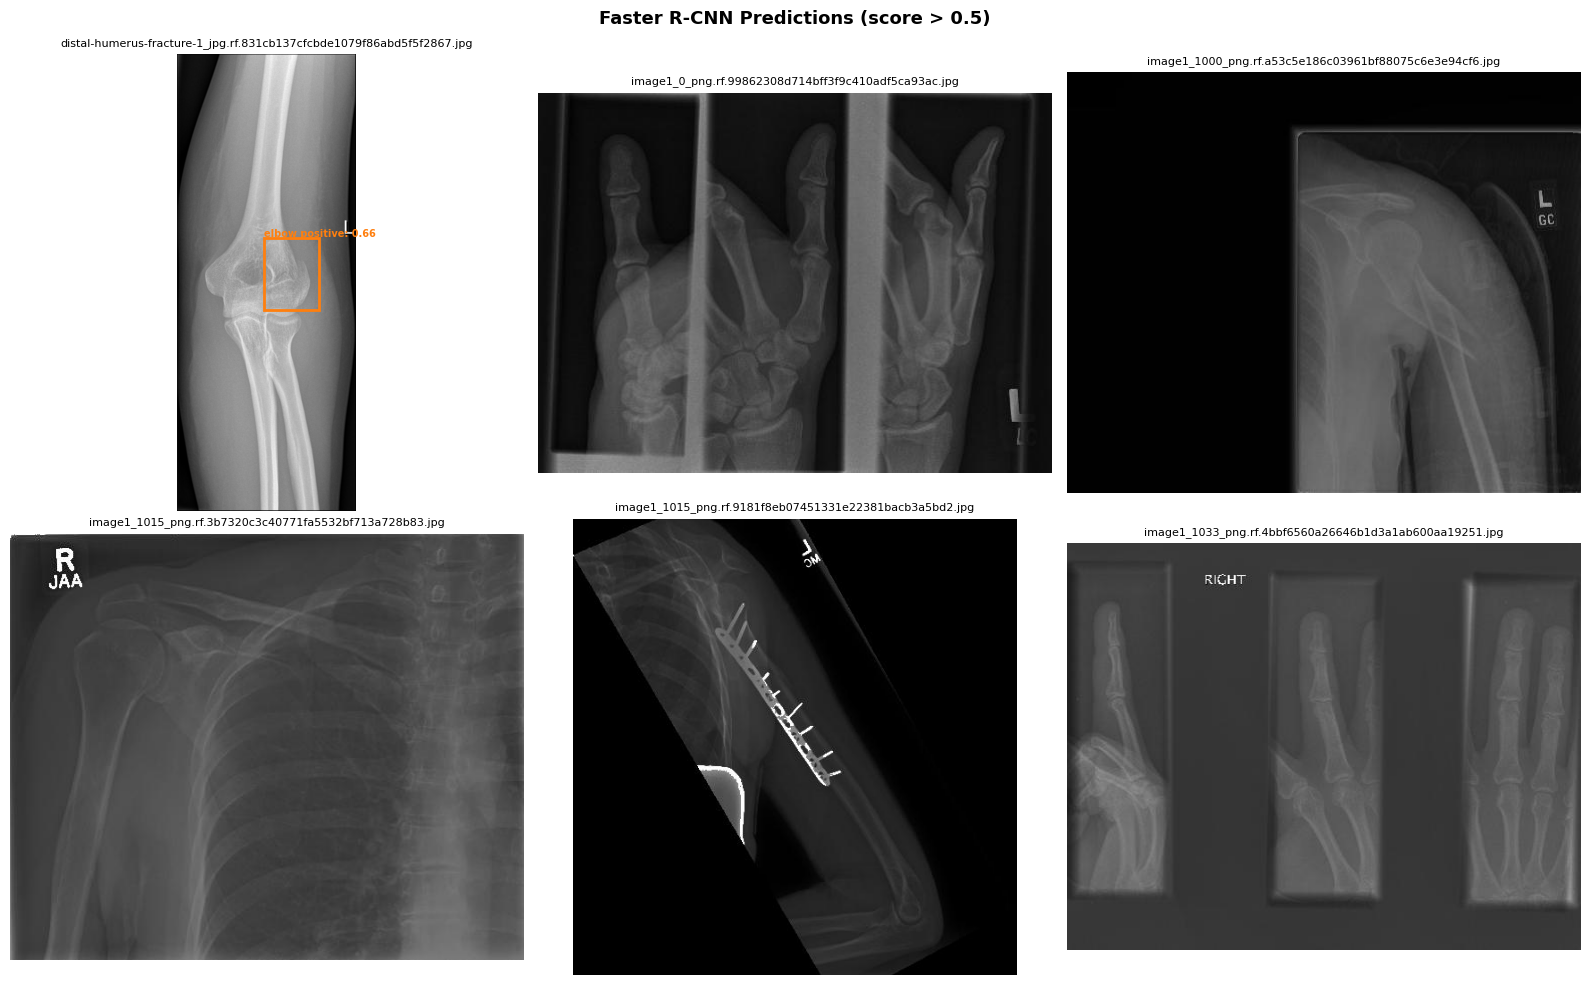

In [10]:
SCORE_THRESHOLD = 0.5
COLORS = plt.cm.get_cmap('tab10', NUM_CLASSES)

model.eval()
sample_files = sorted(os.listdir(test_images))[:6]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

with torch.no_grad():
    for i, fname in enumerate(sample_files):
        img_path = os.path.join(test_images, fname)
        img_pil  = Image.open(img_path).convert('RGB')
        img_t    = transforms.ToTensor()(img_pil).unsqueeze(0).to(DEVICE)

        output = model(img_t)[0]

        ax = axes[i]
        ax.imshow(img_pil)
        ax.set_title(fname, fontsize=8)
        ax.axis('off')

        for box, label, score in zip(output['boxes'], output['labels'], output['scores']):
            if score < SCORE_THRESHOLD:
                continue
            x1, y1, x2, y2 = box.cpu().numpy()
            color = COLORS(label.item())
            rect  = mpatches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                        linewidth=2, edgecolor=color, facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, y1 - 5, f'{CLASS_NAMES[label]}: {score:.2f}',
                    color=color, fontsize=7, fontweight='bold')

plt.suptitle('Faster R-CNN Predictions (score > 0.5)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()